In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pypalettes import load_cmap
import yfinance as yf

# Get Data

In [51]:
PERIOD = "1y"
INTERVAL = "1d"
YTD = True        # limit to year to date if True

TICKERS = {
    "GC=F": "gold",
    "BZ=F": "brent_crude",
    "NG=F": "natural_gas",
    "HG=F": "copper",
    # potential others
    # "SI=F": "silver",
    # "CL=F": "wti",
}

df = (

    # get data from yfinance
    yf.download(
        list(TICKERS.keys()),
        period=PERIOD,
        interval=INTERVAL,
        group_by="column",
        auto_adjust=True
    )

    # select closing prices only
    ["Close"]  

    # rename columns
    .rename(columns=TICKERS)
)

df.index.name = None        # optional: remove index name or lowercase
df.columns.name = None      # optional: remove "Ticker" column axis name

if YTD:
    start_of_year = f"{pd.Timestamp.today().year}-01-01"
    df = df.loc[df.index >= start_of_year]

# calculate percentage change (for each commodity) from start 
# of period using: (current_price / starting_price - 1) * 100

pct = (df / df.iloc[0] - 1) * 100   # equivalent: df.div(df.iloc[0]).sub(1).mul(100)    

[*********************100%***********************]  4 of 4 completed


In [52]:
df.head().round(2)

,brent_crude,gold,copper,natural_gas
2026-01-02,60.75,4314.4,5.64,3.62
2026-01-05,61.76,4436.9,5.92,3.52
2026-01-06,60.70,4482.2,6.01,3.35
2026-01-07,59.96,4449.3,5.81,3.53
2026-01-08,61.99,4449.7,5.75,3.41


In [53]:
pct.head().round(2)

,brent_crude,gold,copper,natural_gas
2026-01-02,0.00,0.00,0.00,0.00
2026-01-05,1.66,2.84,5.04,-2.63
2026-01-06,-0.08,3.89,6.57,-7.41
2026-01-07,-1.30,3.13,3.00,-2.57
2026-01-08,2.04,3.14,1.89,-5.83


# Global Commodities Performance Over Time

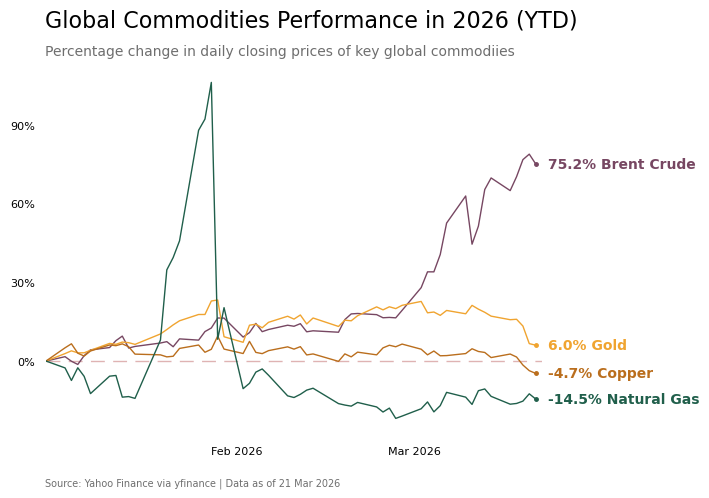

In [60]:
# choose a colour palette
cmap = load_cmap("Autumn")
order = [0, 8, 1, 5, 6, 7]   # expanded to cover 6 commodities
colours = [cmap.colors[idx] for idx in order]

# create figure
fig, ax = plt.subplots()

# axes customisation
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(length=0, pad=8, labelsize=8)
# ax.grid(True, alpha=0.3, axis="y")

# x and y axis labels: dates display and percentages
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(30))   # every 5 units
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

# set axes limits
ax.set_xlim(pct.index.min(), pct.index.max() + pd.Timedelta(days=1))

# y = 0 horizontal line
ax.axhline(
    y=0, 
    linestyle=(0, (10, 6)),  # (offset, (dash_length, gap_length))
    linewidth=1,
    alpha=0.3,
    color="#950404FF"
)

# multi-line time series plot
for i, commodity in enumerate(pct.columns):

    # use a rolling window to average (smoothen) fluctuations over time 
    rolling_pct = pct[commodity].rolling(
        window=1, 
        center=False
    ).mean()

    ax.plot(
        pct.index,
        rolling_pct,
        label=commodity,
        linewidth=1,
        color=colours[i]
    )

    # last data point marker
    ax.scatter(
        pct.index[-1],
        pct[commodity].iloc[-1],
        marker=".",
        s=25,
        color=colours[i]
    )

    # text annotation to highlight commodity
    ax.text(
        x=pct.index[-1] + pd.Timedelta(days=2),
        y=pct[commodity].iloc[-1],
        s=(
            f"{pct[commodity].iloc[-1]:.1f}% "
            f"{commodity.replace('_', ' ').title()}"
        ),
        ha="left",
        va="center",
        color=colours[i],
        fontsize=10,
        weight="bold"
    )

# chart title
x_value, y_value = 0.124, 0.96
fig.text(
    x=x_value,
    y=y_value,
    s="Global Commodities Performance in 2026 (YTD)",
    size=16
)

# chart subtitle
fig.text(
    x=x_value,
    y=y_value * 0.94,
    s=f"Percentage change in daily closing prices of key global commodiies",
    size=10,
    color="#6e6e6e"
)

# chart caption
today_fmt = pd.Timestamp.today().strftime("%d %b %Y")
fig.text(
    x_value, 0,
    s = (
        f"Source: Yahoo Finance via yfinance"
        f" | Data as of {today_fmt}"
    ),
    ha="left",
    va="bottom",
    fontsize=7,
    color="#6e6e6e",
)

plt.savefig("../images/2026_ytd_performance.svg", bbox_inches="tight")

plt.show()